## Validation Approach 2: Thrifty neutral model as baseline

Validate DASM entrenchment predictions using Thrifty-inferred expected mutation counts instead of out-of-frame data. This addresses the limited statistical power of Approach 1 (rates_analysis_productive_non_productive), where many entrenched substitutions lacked sufficient out-of-frame counts.

**Method**: Instead of counting mutations in out-of-frame sequences, we use Thrifty (a kmer-based neutral mutation model) to estimate expected substitution counts for each PCP. Observed counts come from productive sequences, restricted to V-gene-encoded sites and mutations away from the germline amino acid. Leaf nodes are excluded from both observed and expected counts.

Since both observed and Thrifty-predicted expected counts are calculated on the same phylogenetic trees and per-site mutation probabilities are small, branch lengths approximately cancel when taking ratios, allowing direct comparison of counts rather than rates.

For expected counts, Thrifty's neutral mutation rate at each site is converted to a mutation probability using branch lengths calculated as total nucleotide mutation frequency × α (α=1.6). This scaling factor is derived from regressing observed mutation frequencies against DASM-optimized branch lengths (see dasm-epistasis-experiments/branch-length-regression), correcting for the fact that purifying selection removes some expected mutations (1/1.6 ≈ 0.63). Because α is a single global scalar, it adjusts the overall scale of expected counts but cannot introduce a correlation where there is none. The mutation probability is then multiplied by Thrifty's conditional substitution probabilities and summed across PCPs per V family, site, and substitution.

**Datasets**: Jaffe + Tang (productive, DASM training data) for both observed and expected counts. This dataset was used to train DASM, so this validation tests the model but does not test generalization to unseen data. See paper Methods and Table 1 for details.

**Analysis levels**:
1. Per site + parent AA + child AA — compared to DASM selection factors (main validation)
2. Per site + parent codon + child codon — validates that synonymous mutations cluster near neutral while nonsynonymous mutations skew toward purifying selection

**Key results**:
- Count ratios align well with DASM selection factors, with much stronger coverage than Approach 1 (~2,900 of ~3,200 substitutions retained with ≥5 expected counts filter).
- Entrenched sites and substitutions consistently show purifying selection, though some are closer to neutral than DASM predicts.
- Synonymous mutations cluster around neutral, with a slight purifying selection skew — possibly because synonymous changes are not perfectly neutral (e.g., effects on mRNA stability or codon usage) or because Thrifty overestimates rates for very rare mutations.

**Saved figures**: `v1jaffe+v1tang_rates_w_thrifty_*` (DASM vs count ratio scatter, pairwise entrenchment validation for main and supplementary figures).


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from types import SimpleNamespace

from utils import sort_antibody_sites, add_cdr_shading, add_germline_information, load_and_process_dnsm_data, load_and_process_dasm_data, load_entrenched_sites, GERMLINE_PATH_DICTIONARY

from dnsmex.neutral_mutability import CachedNeutralMutabilityDataset

from rates_analysis_util import (
    compare_mutation_rates_on_different_backgrounds_for_all_sites,
    add_mutation_counts_per_branch_for_branch_length,
    plot_dasm_vs_rates_comparison,
    plot_rates_pairwise_analysis,
)


In [2]:
DATASETS = ['v1jaffe', 'v1tang']
DATASET_LABEL = '+'.join(DATASETS)

numbering_scheme = 'chothia'

BRANCH_LENGTH_METHOD = 'mutation_frequency' 

# Scaling factor derived from regressing observed mutation frequencies against 
# DASM-optimized branch lengths (see Methods in paper and dasm-epistasis-experiments/branch-length-regression)
BRANCH_LENGTH_SCALE_FACTOR = 1.60


# entrenchment analysis comparison parameters
dasm_compare_dataset_name = "v1rodriguez"
dasm_compare_model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"


In [3]:
## load and prepare data for **observed** mutation counts

In [ ]:
## calculate observed mutation counts
## branch length method doesn't actually matter here because we are using the ratio of observed to expected counts (same pcp dataset, so same branch lengths will cancel out anyway)
## LEAF FILTERING: Leaves are excluded via remove_leaves=True in compare_mutation_rates_on_different_backgrounds_for_all_sites

output_dirs = ['_ignore/observed_counts_from_productive']
for dir in output_dirs:
    if not os.path.exists(dir):
        os.makedirs(dir, exist_ok=True)

branch_length_method = 'total_mutation_freq_branch'

output_base_path = f'_ignore/observed_counts_from_productive/observed_mutation_rates_{DATASET_LABEL}_bl_{branch_length_method}_{numbering_scheme}'

# load substitution occurences and sum counts across datasets, DNSM outputs aren't used here
all_site_sub_probs = []
all_pcp_dfs = []
pcp_offset = 0

for ds in DATASETS:
    print(f"Loading observed data for {ds}...")
    site_df, pcp_df_single = load_and_process_dnsm_data(
        model_name="dnsm_1m-v1jaffe+v1tang-joint",
        dataset_name=ds, numbering_scheme=numbering_scheme
    )
    # Offset pcp_index to avoid collisions between datasets
    site_df['pcp_index'] = site_df['pcp_index'] + pcp_offset
    pcp_df_single = pcp_df_single.copy()
    pcp_df_single.index = pcp_df_single.index + pcp_offset
    pcp_offset += len(pcp_df_single)
    all_site_sub_probs.append(site_df)
    all_pcp_dfs.append(pcp_df_single)

site_sub_probs_df_germline_total = pd.concat(all_site_sub_probs, ignore_index=True)
total_pcp_df = pd.concat(all_pcp_dfs)  # preserve offset index - it IS the pcp_index

site_sub_probs_df_germline_total = add_mutation_counts_per_branch_for_branch_length(site_sub_probs_df_germline_total)
compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline_total, output_base_path, branch_length_method=branch_length_method, remove_leaves=True, pcp_df=total_pcp_df)

observed_aa_df = pd.read_csv(f'{output_base_path}_per_aa_mutation_rates.csv', dtype={'site':str})
observed_aa_df = observed_aa_df.rename(columns={
    'mutation_acquired': 'observed_counts',
    'mutation_acquired_adjusted': 'observed_counts_adjusted',
    'mutcount_length': 'mutcount_length_observed'
}).drop(columns=['rate_mutcount', 'rate_mutcount_adjusted'])
observed_aa_df


Loading observed data for v1jaffe...


Loading observed data for v1tang...


Removing leaf nodes from the analysis


Processing 151 sites...
Processing site 1/151: site 1


Processing site 11/151: site 11


...

No data for V family IGHV1 at site 112
No data for V family IGHV3 at site 112
No data for V family IGHV4 at site 112
No data for V family IGHV1 at site 113
No data for V family IGHV3 at site 113
No data for V family IGHV4 at site 113


No data for V family IGHV1 at site 104A
No data for V family IGHV3 at site 104A
No data for V family IGHV4 at site 104A
No data for V family IGHV1 at site 104B
No data for V family IGHV3 at site 104B
No data for V family IGHV4 at site 104B


No data for V family IGHV1 at site 104C
No data for V family IGHV3 at site 104C
No data for V family IGHV4 at site 104C
Processing site 151/151: site 104D


No data for V family IGHV1 at site 104D
No data for V family IGHV3 at site 104D
No data for V family IGHV4 at site 104D
Converting results to DataFrames...
Saving overall results to _ignore/observed_counts_from_productive/observed_mutation_rates_v1jaffe+v1tang_bl_total_mutation_freq_branch_chothia_overall_mutation_rates.csv
Overall results: 297 rows saved
Saving per-amino acid results to _ignore/observed_counts_from_productive/observed_mutation_rates_v1jaffe+v1tang_bl_total_mutation_freq_branch_chothia_per_aa_mutation_rates.csv
Per-AA results: 10165 rows saved
Saving per-codon results to _ignore/observed_counts_from_productive/observed_mutation_rates_v1jaffe+v1tang_bl_total_mutation_freq_branch_chothia_per_codon_mutation_rates.csv
Per-codon results: 6255 rows saved


,v_family,site,parent_aa,child_aa,mutcount_length_observed,observed_counts,observed_counts_adjusted
0,IGHV1,1,Q,A,426.307204,0,0.5
1,IGHV1,1,Q,C,426.307204,0,0.5
2,IGHV1,1,Q,D,426.307204,0,0.5
3,IGHV1,1,Q,E,426.307204,23,23.5
4,IGHV1,1,Q,F,426.307204,0,0.5
...,...,...,...,...,...,...,...
10160,IGHV4,94,R,S,483.416424,70,70.5
10161,IGHV4,94,R,T,483.416424,91,91.5
10162,IGHV4,94,R,V,483.416424,1,1.5
10163,IGHV4,94,R,W,483.416424,1,1.5


In [5]:
# Validate combined observed data
assert total_pcp_df.index.is_unique, "pcp_df has duplicate indices after combining datasets!"
assert len(total_pcp_df) == sum(len(df) for df in all_pcp_dfs), "pcp_df row count mismatch"
print(f"Combined observed data: {len(total_pcp_df):,} PCPs across {len(DATASETS)} datasets")
for ds, pdf in zip(DATASETS, all_pcp_dfs):
    print(f"  {ds}: {len(pdf):,} PCPs")


Combined observed data: 751,369 PCPs across 2 datasets
  v1jaffe: 228,789 PCPs
  v1tang: 522,580 PCPs


In [6]:
# Assert that observed counts from rates calculation file match direct computation from site_sub_probs_df
# This validates that observed counts are computed consistently with expected counts

pcp_indices_non_leaf = total_pcp_df[~total_pcp_df['child_is_leaf']].index
observed_aa_df_test = site_sub_probs_df_germline_total[
      (site_sub_probs_df_germline_total.is_germline_codon == True) &
      (site_sub_probs_df_germline_total.pcp_index.isin(pcp_indices_non_leaf)) &
      (site_sub_probs_df_germline_total.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))      
  ].groupby(['site', 'parent_aa', 'v_family', 'child_aa']).mutation.sum().reset_index()


observed_aa_df_test = observed_aa_df_test[
    (observed_aa_df_test.mutation > 0)
].rename(columns={'mutation':'observed_counts'})[
    ['v_family', 'site', 'parent_aa', 'child_aa','observed_counts']
].sort_values(['v_family', 'site', 'parent_aa', 'child_aa']).reset_index(drop=True)

observed_from_rates = observed_aa_df[
    (observed_aa_df.observed_counts > 0)
][['v_family', 'site', 'parent_aa', 'child_aa','observed_counts']].sort_values(
    ['v_family', 'site', 'parent_aa', 'child_aa']
).reset_index(drop=True)

assert observed_aa_df_test.equals(observed_from_rates), \
    "Observed counts from direct computation don't match cached file!"

In [7]:
# load thrifty neutral model **expected** mutation counts
# Updated to use new CachedNeutralMutabilityDataset from dnsm-experiments-1
# Loads each dataset separately with pcp_index offset, then combines

all_aa_neutral, all_aa_to_any_neutral = [], []
all_codon_neutral, all_codon_to_any_neutral = [], []
all_neutral_pcp_dfs = []
pcp_offset = 0

for ds in DATASETS:
    print(f"Loading expected data for {ds}...")
    neutral_ds = CachedNeutralMutabilityDataset(
        dataset_nickname=ds,
        branch_length_mode=BRANCH_LENGTH_METHOD,
        branch_length_scale_factor=BRANCH_LENGTH_SCALE_FACTOR,
        numbering_scheme=numbering_scheme,
        skip_nucleotide=True,
    )
    # Offset pcp_index to avoid collisions between datasets
    neutral_ds.pcp_df = neutral_ds.pcp_df.copy()
    neutral_ds.pcp_df.index = neutral_ds.pcp_df.index + pcp_offset
    for attr in ['aa_neutral_df', 'aa_to_any_neutral_df',
                 'codon_neutral_df', 'codon_to_any_neutral_df']:
        getattr(neutral_ds, attr)['pcp_index'] = getattr(neutral_ds, attr)['pcp_index'] + pcp_offset

    all_aa_neutral.append(neutral_ds.aa_neutral_df)
    all_aa_to_any_neutral.append(neutral_ds.aa_to_any_neutral_df)
    all_codon_neutral.append(neutral_ds.codon_neutral_df)
    all_codon_to_any_neutral.append(neutral_ds.codon_to_any_neutral_df)
    all_neutral_pcp_dfs.append(neutral_ds.pcp_df)
    pcp_offset += len(neutral_ds.pcp_df)

neutral_probabilties = SimpleNamespace(
    pcp_df=pd.concat(all_neutral_pcp_dfs),  # preserve offset index
    aa_neutral_df=pd.concat(all_aa_neutral, ignore_index=True),
    aa_to_any_neutral_df=pd.concat(all_aa_to_any_neutral, ignore_index=True),
    codon_neutral_df=pd.concat(all_codon_neutral, ignore_index=True),
    codon_to_any_neutral_df=pd.concat(all_codon_to_any_neutral, ignore_index=True),
)

# add germline information to all dataframes
neutral_probabilties.aa_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.aa_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.aa_to_any_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.aa_to_any_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.codon_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.codon_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.codon_to_any_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.codon_to_any_neutral_df, numbering_scheme=numbering_scheme)

# LEAF FILTERING for expected data: Manually filter out leaf nodes to match observed data
# (observed uses remove_leaves=True in compare_mutation_rates_on_different_backgrounds_for_all_sites)
pcp_indices_non_leaf = neutral_probabilties.pcp_df[~neutral_probabilties.pcp_df['child_is_leaf']].index
# probabilities sum to counts
expected_aa_df = neutral_probabilties.aa_neutral_df[
      (neutral_probabilties.aa_neutral_df.is_germline_codon == True) &
      (neutral_probabilties.aa_neutral_df.pcp_index.isin(pcp_indices_non_leaf))
  ].groupby(['site', 'current_aa', 'v_family', 'transition_aa']).substitution_probability.sum().reset_index()
expected_aa_df

Loading expected data for v1jaffe...
Loading NeutralMutabilityDataset data from gzip cache...


✓ Loaded from gzip cache:
  - Nucleotide DataFrame: skipped
  - Amino Acid DataFrame: 195,090,853 rows
  - Amino Acid to Any DataFrame: 27,803,432 rows
  - Codon DataFrame: 250,230,888 rows
  - Codon to Any DataFrame: 27,803,432 rows
  - PCP DataFrame: 228,789 rows


Loading expected data for v1tang...
Loading NeutralMutabilityDataset data from gzip cache...


✓ Loaded from gzip cache:
  - Nucleotide DataFrame: skipped
  - Amino Acid DataFrame: 445,297,648 rows
  - Amino Acid to Any DataFrame: 63,422,647 rows
  - Codon DataFrame: 570,803,823 rows
  - Codon to Any DataFrame: 63,422,647 rows
  - PCP DataFrame: 522,580 rows


,site,current_aa,v_family,transition_aa,substitution_probability
0,1,E,IGHV1,*,0.683951
1,1,E,IGHV1,A,0.488193
2,1,E,IGHV1,D,1.545478
3,1,E,IGHV1,E,1.272324
4,1,E,IGHV1,G,0.886557
...,...,...,...,...,...
7025,94,T,IGHV3,K,21.625504
7026,94,T,IGHV3,P,32.034596
7027,94,T,IGHV3,R,28.506201
7028,94,T,IGHV3,S,28.041862


In [8]:
# Validate combined expected data
assert neutral_probabilties.pcp_df.index.is_unique, "Expected pcp_df has duplicate indices!"
print(f"Combined expected data: {len(neutral_probabilties.pcp_df):,} PCPs")
for ds, pdf in zip(DATASETS, all_neutral_pcp_dfs):
    print(f"  {ds}: {len(pdf):,} PCPs")
print(f"  aa_neutral_df: {len(neutral_probabilties.aa_neutral_df):,} rows")
print(f"  codon_neutral_df: {len(neutral_probabilties.codon_neutral_df):,} rows")
print(f"\nExpected AA groupby count: {len(expected_aa_df):,} unique (v_family, site, parent_aa, child_aa) groups")

Combined expected data: 751,369 PCPs
  v1jaffe: 228,789 PCPs
  v1tang: 522,580 PCPs
  aa_neutral_df: 640,388,501 rows
  codon_neutral_df: 821,034,711 rows

Expected AA groupby count: 7,030 unique (v_family, site, parent_aa, child_aa) groups


<Axes: >

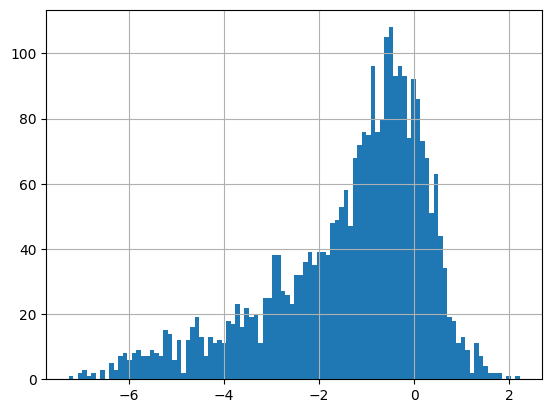

In [9]:
# merge observed and expected counts - ratio should be the selection factor.

merge_counts = pd.merge(expected_aa_df.rename(columns={'current_aa':'parent_aa', 'transition_aa':'child_aa', 'substitution_probability':'expected_counts'}), observed_aa_df, on=['v_family', 'site', 'parent_aa', 'child_aa'])

# Use adjusted counts (with pseudocount already applied)
# For expected counts from Thrifty, we add pseudocount here since Thrifty doesn't have it built in
pseudocount = 0.5
merge_counts['ratio'] = merge_counts['observed_counts_adjusted'] / (merge_counts['expected_counts'] + pseudocount)
merge_counts['log_ratio'] = np.log(merge_counts['ratio'])

merge_counts[merge_counts.expected_counts >= 5].log_ratio.hist(bins=100)

## load entrenches sites identified by DASM analysis

We separate sites into two types of evolutionarily constrained sites:
- Within v family entrenched sites
- Between v-family entrenched sites

Here we plot both types together, since we just want to make sure our entrenched sites are not edge cases with low counts.

In [10]:
# Load entrenched sites using consolidated function from utils
entrenched_sites, entrenched_sites_aas, pairwise_df_dict, SITE_COLOR_MAP, within_dfs, vs_dfs = load_entrenched_sites(numbering_scheme)

print(f"Loaded {len(entrenched_sites)} entrenched sites")
print(f"Loaded {len(entrenched_sites_aas)} entrenched site-aa pairs")
print(f"Created color mapping for {len(SITE_COLOR_MAP)} sites")

Loaded 37 entrenched sites
Loaded 83 entrenched site-aa pairs
Created color mapping for 15 sites


## Compare rate ratio to DASM

In [11]:
### compare to DASM


_, _, aa_site_subs_selection_df_germline = load_and_process_dasm_data(model_name=dasm_compare_model_name, dataset_name=dasm_compare_dataset_name, numbering_scheme=numbering_scheme)

# Aggregate matching the entrenchment analysis in v_families_dasm.ipynb
before_grouping = aa_site_subs_selection_df_germline[
    (aa_site_subs_selection_df_germline.depth == 2) &
    (aa_site_subs_selection_df_germline.one_mutation_away == True) &
    (aa_site_subs_selection_df_germline.is_germline_codon == True)
].copy()
before_grouping.dropna(subset=['log_selection_factor'], inplace=True)

# Remove rare AAs (< 10 unique PCPs per v_family+site+parent_aa)
counts_of_aa_site_family = before_grouping[['v_family', 'site', 'parent_aa', 'pcp_index']].drop_duplicates().groupby(['v_family', 'site', 'parent_aa']).size().reset_index(name='count')
counts_of_aa_site_family = counts_of_aa_site_family[counts_of_aa_site_family['count'] >= 10]
before_grouping = pd.merge(before_grouping, counts_of_aa_site_family[['v_family', 'site', 'parent_aa']], on=['v_family', 'site', 'parent_aa'], how='inner')

dasm_summarized = before_grouping.groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).log_selection_factor.median().reset_index()

Adding one_mutation_away column (vectorized)...


Plotting 83 entrenched points


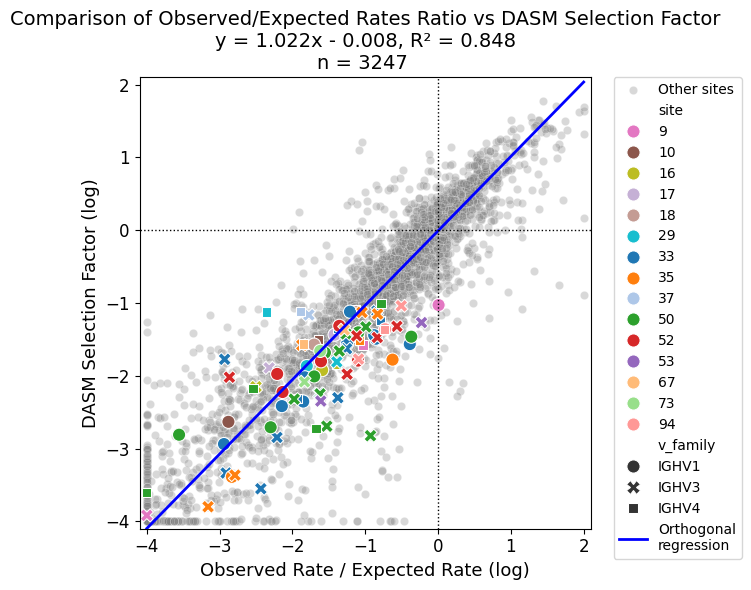

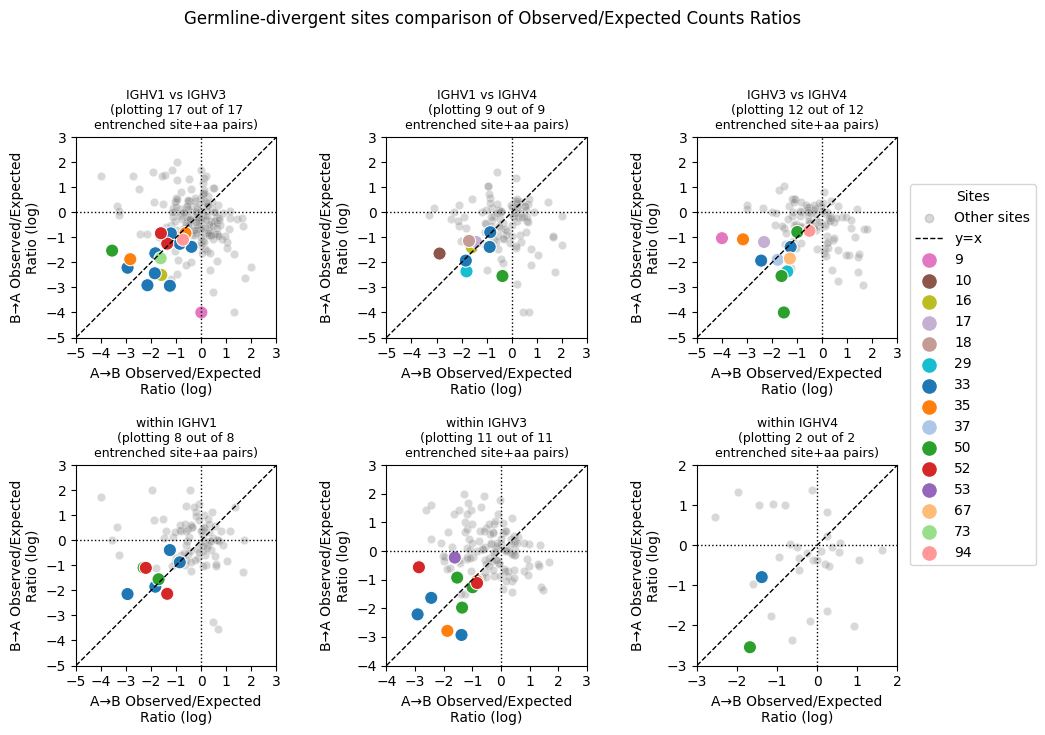

In [12]:
## show unfiltered data

compare_dasm_rates = pd.merge(merge_counts, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates.to_csv(f'figures/rates_productive_w_thrifty_{DATASET_LABEL}_compare_dasm_rates_unfiltered.csv', index=False)

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, SITE_COLOR_MAP)
plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, SITE_COLOR_MAP)

Plotting 76 entrenched points
The following entrenched points were not found in the comparison data:
     site v_family parent_aa child_aa
504    29    IGHV4         V        F
756    33    IGHV4         S        Y
1229   50    IGHV1         R        S
1230   50    IGHV1         R        W
1351   52    IGHV1         D        V
1373   52    IGHV1         V        D
2861   94    IGHV1         T        K


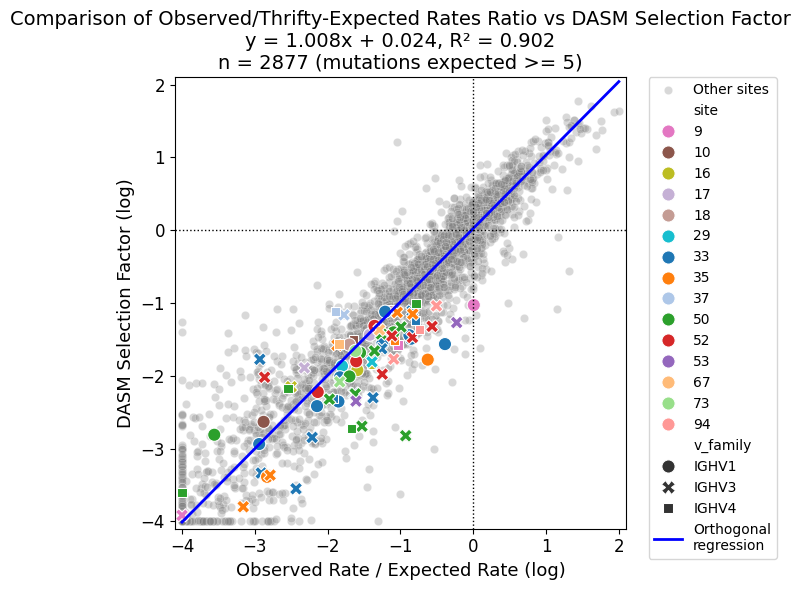

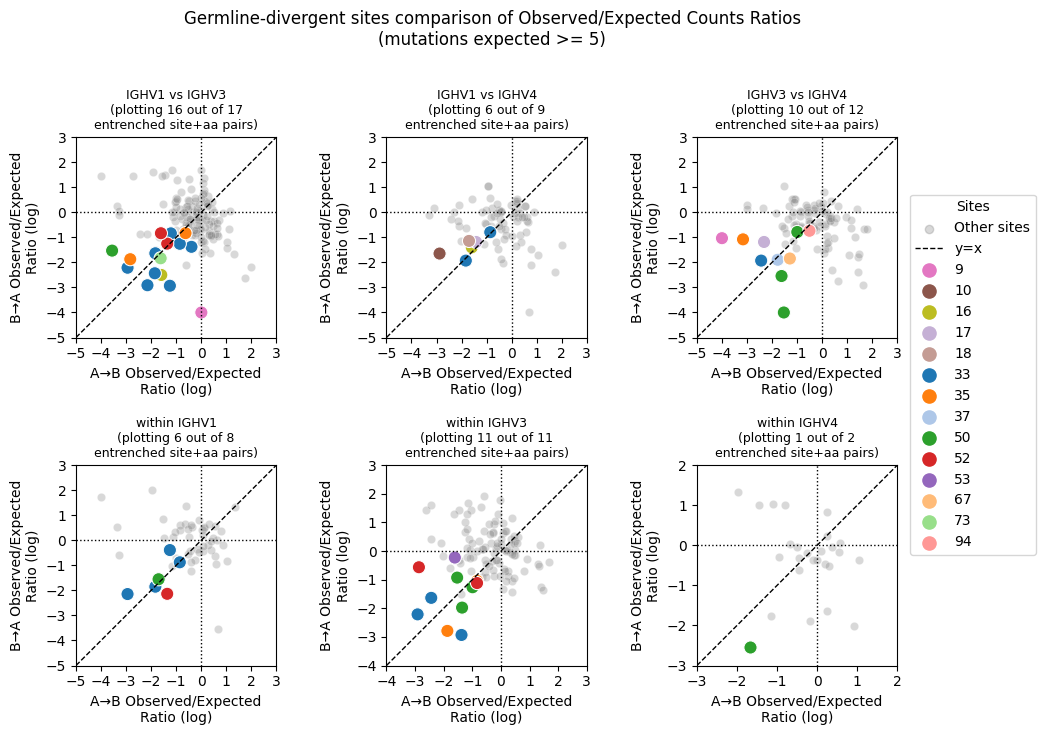

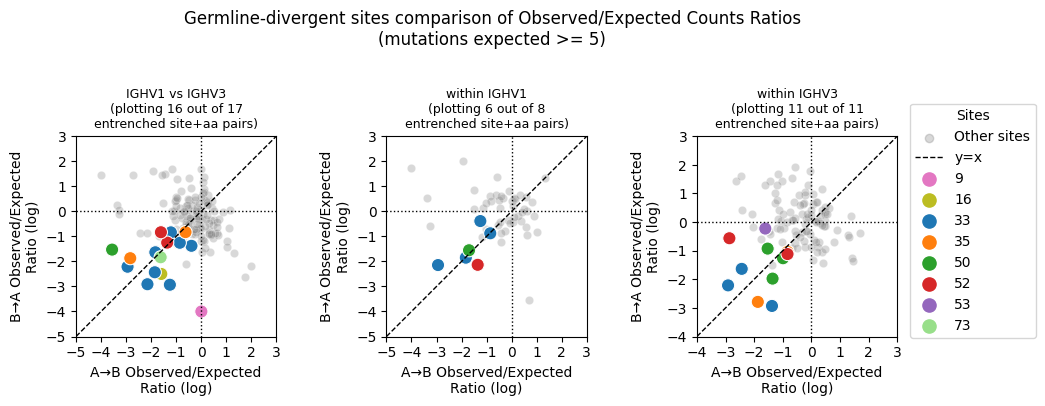

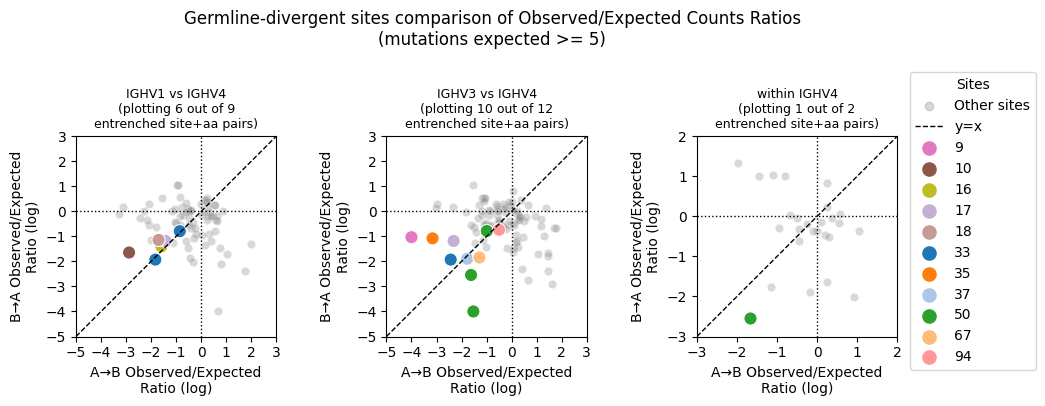

In [13]:
# show filtered data

compare_dasm_rates = pd.merge(merge_counts, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

compare_dasm_rates = compare_dasm_rates[compare_dasm_rates.expected_counts >= 5]

plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, SITE_COLOR_MAP, 
                              savefig_prefix=f'{DATASET_LABEL}_rates_w_thrifty_', 
                              title="Comparison of Observed/Thrifty-Expected Rates Ratio vs DASM Selection Factor",
                              title_extra='(mutations expected >= 5)')

plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, SITE_COLOR_MAP, 
                             savefig_prefix=f'{DATASET_LABEL}_rates_w_thrifty_', title_extra='(mutations expected >= 5)')

# Main figure (no IGHV4)
plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, SITE_COLOR_MAP, 
    panels=['IGHV1_vs_IGHV3', 'within_IGHV1', 'within_IGHV3'],
    savefig_prefix=f'{DATASET_LABEL}_rates_w_thrifty_main_',
    title_extra='(mutations expected >= 5)')

# Supplementary figure (with IGHV4)
plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, SITE_COLOR_MAP, 
    panels=['IGHV1_vs_IGHV4', 'IGHV3_vs_IGHV4', 'within_IGHV4'],
    savefig_prefix=f'{DATASET_LABEL}_rates_w_thrifty_supp_',
    title_extra='(mutations expected >= 5)')


## Validation: Synonymous vs Non-synonymous Mutations

Test that synonymous mutations have log count ratios centered around 0 (neutral), while non-synonymous mutations show a broader distribution with more negative values (purifying selection).

This analysis uses codon-level counts to separate synonymous from non-synonymous changes.

In [14]:
# Filter expected data to exclude leaves (to match observed):
pcp_indices_non_leaf = neutral_probabilties.pcp_df[~neutral_probabilties.pcp_df['child_is_leaf']].index
# Get codon-level expected counts from Thrifty
expected_codon_df = neutral_probabilties.codon_neutral_df[
    (neutral_probabilties.codon_neutral_df.is_germline_codon == True) & 
    (neutral_probabilties.codon_neutral_df.pcp_index.isin(pcp_indices_non_leaf))
].groupby(['site', 'current_codon', 'v_family', 'transition_codon']).substitution_probability.sum().reset_index()


expected_codon_df = expected_codon_df.rename(columns={
    'current_codon': 'parent_codon', 
    'transition_codon': 'child_codon', 
    'substitution_probability': 'expected_counts'
})

# Add parent_aa and child_aa columns
from Bio.Seq import Seq

expected_codon_df['parent_aa'] = expected_codon_df['parent_codon'].apply(
    lambda x: str(Seq(x).translate()) if len(x) == 3 else 'X'
)
expected_codon_df['child_aa'] = expected_codon_df['child_codon'].apply(
    lambda x: str(Seq(x).translate()) if len(x) == 3 else 'X'
)

expected_codon_df

,site,parent_codon,v_family,child_codon,expected_counts,parent_aa,child_aa
0,1,CAA,IGHV1,AAA,0.700182,Q,K
1,1,CAA,IGHV1,CAC,2.021359,Q,H
2,1,CAA,IGHV1,CAG,2.435723,Q,Q
3,1,CAA,IGHV1,CAT,1.878474,Q,H
4,1,CAA,IGHV1,CCA,1.545828,Q,P
...,...,...,...,...,...,...,...
10237,94,GCA,IGHV1,GCG,1.531585,A,A
10238,94,GCA,IGHV1,GCT,0.672222,A,A
10239,94,GCA,IGHV1,GGA,0.794917,A,G
10240,94,GCA,IGHV1,GTA,0.752735,A,V


In [15]:
# Load observed codon-level counts
observed_codon_df = pd.read_csv(f'{output_base_path}_per_codon_mutation_rates.csv', dtype={'site':str})
observed_codon_df = observed_codon_df.rename(
    columns={
        'mutation_acquired': 'observed_counts',
        'mutation_acquired_adjusted': 'observed_counts_adjusted'
    }
).drop(columns=['rate_mutcount', 'rate_mutcount_adjusted', 'mutcount_length'])

# Merge observed and expected codon counts
merge_codon_counts = pd.merge(
    expected_codon_df,
    observed_codon_df, 
    on=['v_family', 'site', 'parent_codon', 'child_codon', 'parent_aa', 'child_aa'],
    how='inner'
)

# Use adjusted counts (with pseudocount already applied to observed)
# For expected counts from Thrifty, we add pseudocount here since Thrifty doesn't have it built in
pseudocount = 0.5
merge_codon_counts['ratio'] = merge_codon_counts['observed_counts_adjusted'] / (merge_codon_counts['expected_counts'] + pseudocount)
merge_codon_counts['log_ratio'] = np.log(merge_codon_counts['ratio'])

merge_codon_counts

,site,parent_codon,v_family,child_codon,expected_counts,parent_aa,child_aa,observed_counts,observed_counts_adjusted,ratio,log_ratio
0,1,CAA,IGHV1,AAA,0.700182,Q,K,0,0.5,0.416604,-0.875620
1,1,CAA,IGHV1,CAC,2.021359,Q,H,2,2.5,0.991529,-0.008507
2,1,CAA,IGHV1,CAG,2.435723,Q,Q,14,14.5,4.939158,1.597195
3,1,CAA,IGHV1,CAT,1.878474,Q,H,0,0.5,0.210219,-1.559606
4,1,CAA,IGHV1,CCA,1.545828,Q,P,0,0.5,0.244400,-1.408950
...,...,...,...,...,...,...,...,...,...,...,...
6250,94,GCA,IGHV1,GCG,1.531585,A,A,3,3.5,1.722792,0.543946
6251,94,GCA,IGHV1,GCT,0.672222,A,A,1,1.5,1.279621,0.246564
6252,94,GCA,IGHV1,GGA,0.794917,A,G,0,0.5,0.386125,-0.951594
6253,94,GCA,IGHV1,GTA,0.752735,A,V,0,0.5,0.399127,-0.918477


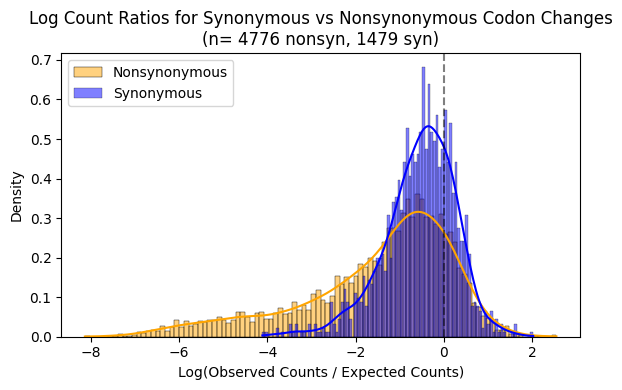

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

# Filter data
nonsynonymous = merge_codon_counts[
    merge_codon_counts.parent_aa != merge_codon_counts.child_aa
].log_ratio

synonymous = merge_codon_counts[
    merge_codon_counts.parent_aa == merge_codon_counts.child_aa
].log_ratio

sns.histplot(nonsynonymous, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100, color='orange')
sns.histplot(synonymous, ax=ax, label='Synonymous', kde=True, stat='density', alpha=0.5, bins=100, color='blue')

ax.legend()
ax.set_xlabel('Log(Observed Counts / Expected Counts)')
ax.set_title('Log Count Ratios for Synonymous vs Nonsynonymous Codon Changes\n(n= {} nonsyn, {} syn)'.format(len(nonsynonymous), len(synonymous)))
ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='Neutral (ratio=1)')
plt.tight_layout()
plt.show()

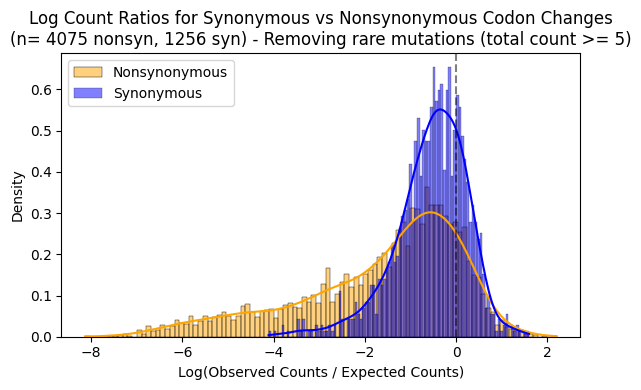


Summary statistics (filtered data):
Synonymous mutations - Mean log ratio: -0.546, Median: -0.453
Nonsynonymous mutations - Mean log ratio: -1.644, Median: -1.163


In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

# Filter data - remove rare mutations
min_count_threshold = 5

nonsynonymous = merge_codon_counts[
    (merge_codon_counts.parent_aa != merge_codon_counts.child_aa) &
    (merge_codon_counts['expected_counts'] >= min_count_threshold)
].log_ratio

synonymous = merge_codon_counts[
    (merge_codon_counts.parent_aa == merge_codon_counts.child_aa) &
    (merge_codon_counts['expected_counts'] >= min_count_threshold)
].log_ratio

sns.histplot(nonsynonymous, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100, color='orange')
sns.histplot(synonymous, ax=ax, label='Synonymous', kde=True, stat='density', alpha=0.5, bins=100, color='blue')

ax.legend()
ax.set_xlabel('Log(Observed Counts / Expected Counts)')
ax.set_title('Log Count Ratios for Synonymous vs Nonsynonymous Codon Changes\n(n= {} nonsyn, {} syn) - Removing rare mutations (total count >= {})'.format(
    len(nonsynonymous), len(synonymous), min_count_threshold))
ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='Neutral (ratio=1)')
plt.tight_layout()
plt.show()

print(f"\nSummary statistics (filtered data):")
print(f"Synonymous mutations - Mean log ratio: {synonymous.mean():.3f}, Median: {synonymous.median():.3f}")
print(f"Nonsynonymous mutations - Mean log ratio: {nonsynonymous.mean():.3f}, Median: {nonsynonymous.median():.3f}")